## 1. Load the data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('housing.csv')
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Preprocessing

### 2.1 Missing values
`total_bedrooms` has some missing values — fill with the mean

In [22]:
print(df.isnull().sum())
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
print('\nMissing after fill:', df['total_bedrooms'].isnull().sum())

longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

Missing after fill: 0


### 2.2 Feature engineering
Add a few ratio features that are more informative than raw counts.

In [23]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


### 2.3 Encode categorical variable
One-hot encode `ocean_proximity`.

In [24]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


### 2.4 Fix dummy column dtypes
`pd.get_dummies` produces boolean columns in recent pandas, which breaks `.quantile()` and other numeric ops — cast them to int.

In [25]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.dtypes

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
median_house_value            float64
rooms_per_household           float64
bedrooms_per_room             float64
population_per_household      float64
ocean_proximity_INLAND          int64
ocean_proximity_ISLAND          int64
ocean_proximity_NEAR BAY        int64
ocean_proximity_NEAR OCEAN      int64
dtype: object

### 2.5 Remove outliers
Cap `median_house_value` at 500001 (dataset's known ceiling artifact) is common practice — here we just drop those capped rows so the regression target isn't distorted.

In [26]:
before = len(df_encoded)
df_encoded = df_encoded[df_encoded['median_house_value'] < 500001]
print(f'Dropped {before - len(df_encoded)} capped rows, {len(df_encoded)} remaining')

Dropped 965 capped rows, 19675 remaining


### 2.6 IQR check (optional)
Now that dummy columns are numeric, IQR calculations work across the whole frame without error.

In [27]:
Q1 = df_encoded.quantile(0.25)
Q3 = df_encoded.quantile(0.75)
IQR = Q3 - Q1
IQR

longitude                          3.770000
latitude                           3.800000
housing_median_age                19.000000
total_rooms                     1682.000000
total_bedrooms                   346.000000
population                       950.000000
households                       324.000000
median_income                      2.055800
median_house_value            131600.000000
rooms_per_household                1.556109
bedrooms_per_room                  0.063824
population_per_household           0.859408
ocean_proximity_INLAND             1.000000
ocean_proximity_ISLAND             0.000000
ocean_proximity_NEAR BAY           0.000000
ocean_proximity_NEAR OCEAN         0.000000
dtype: float64

## 3. Visualization

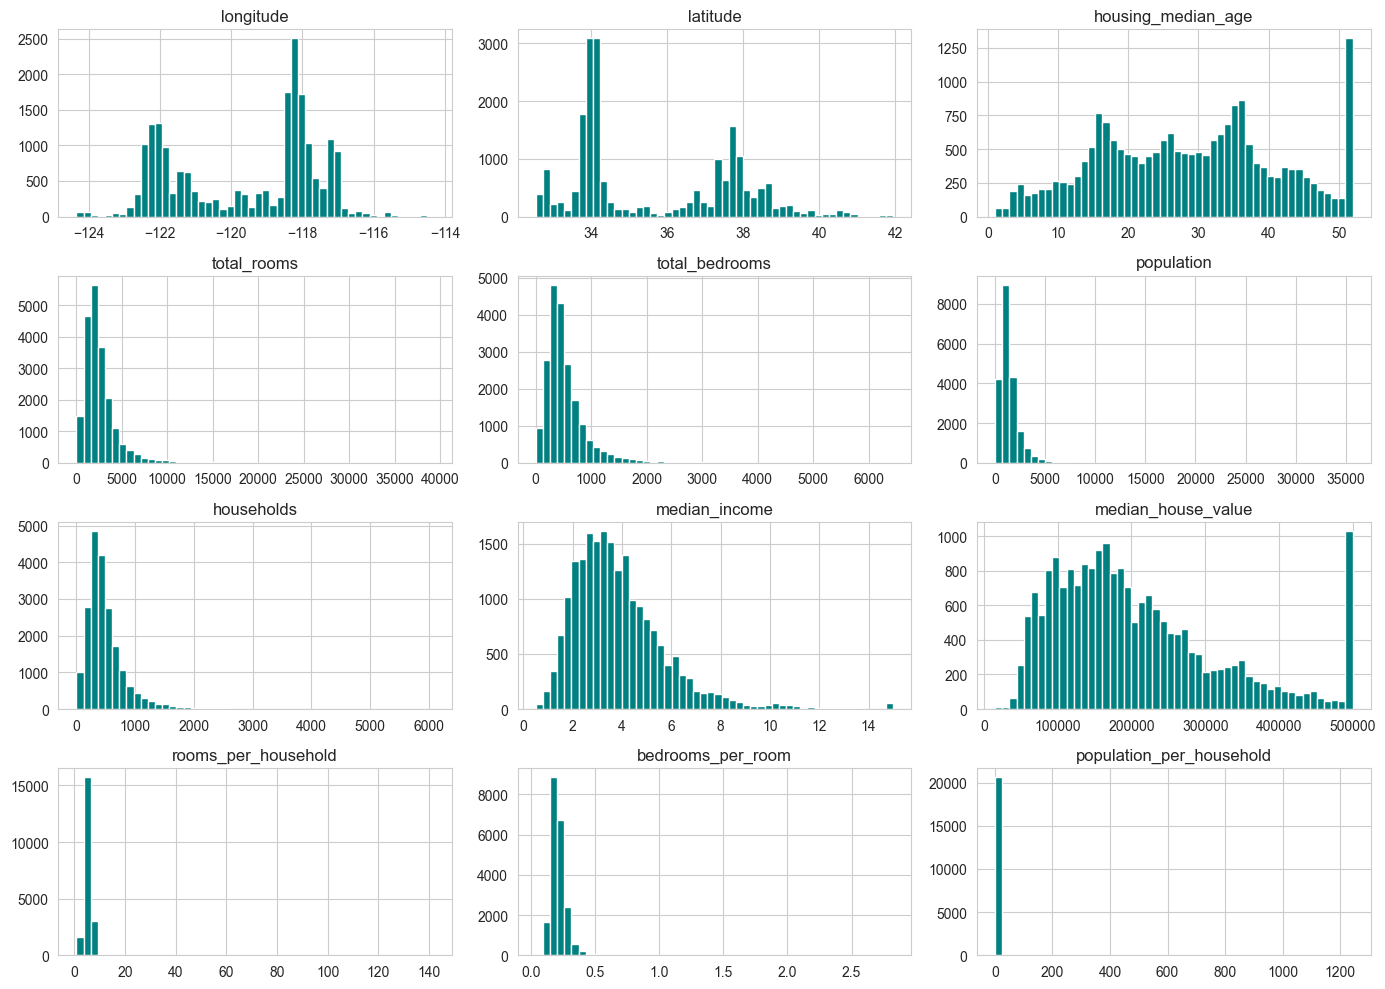

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df.hist(bins=50, figsize=(14, 10), color='teal', edgecolor='white')
plt.tight_layout()
plt.savefig('viz_histograms.png', dpi=100)
plt.show()

### Geographic distribution
Housing value by location (size = population, color = price).

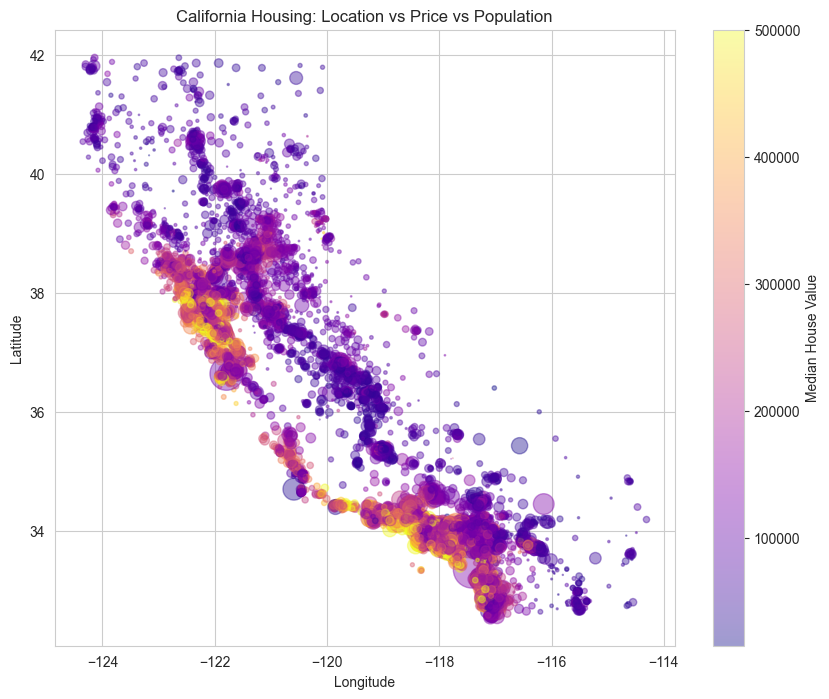

In [29]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.4,
                  s=df['population']/50, c=df['median_house_value'],
                  cmap='plasma')
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('California Housing: Location vs Price vs Population')
plt.savefig('viz_geo.png', dpi=100)
plt.show()

### Correlation heatmap

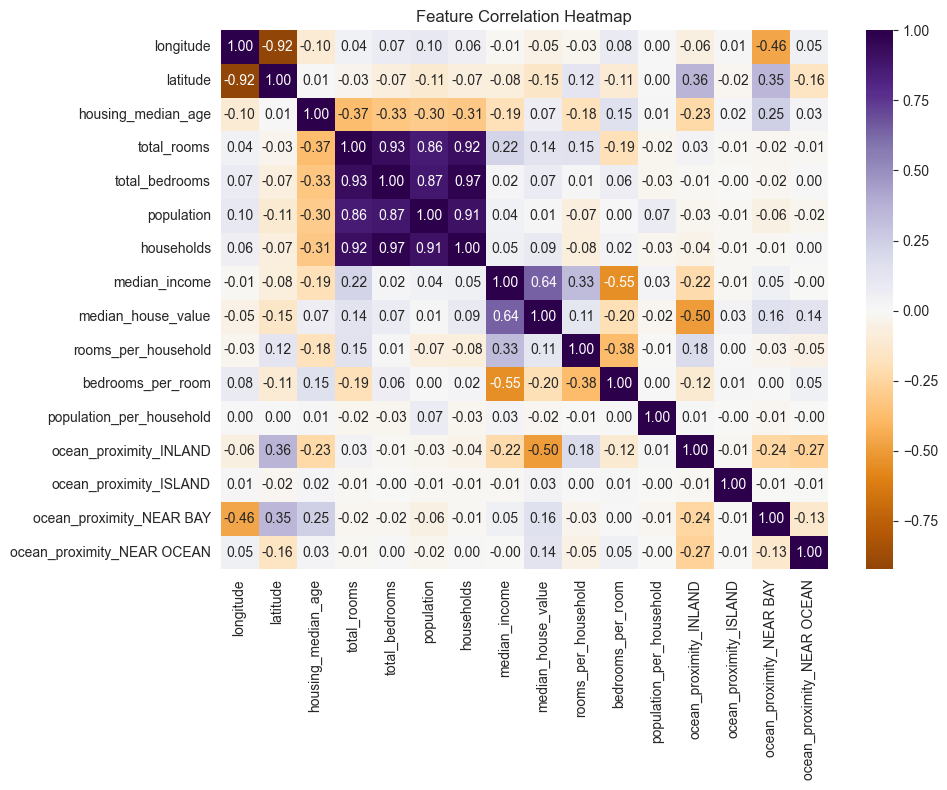

In [30]:
plt.figure(figsize=(10, 8))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='PuOr', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('viz_corr.png', dpi=100)
plt.show()

### Median income vs house value

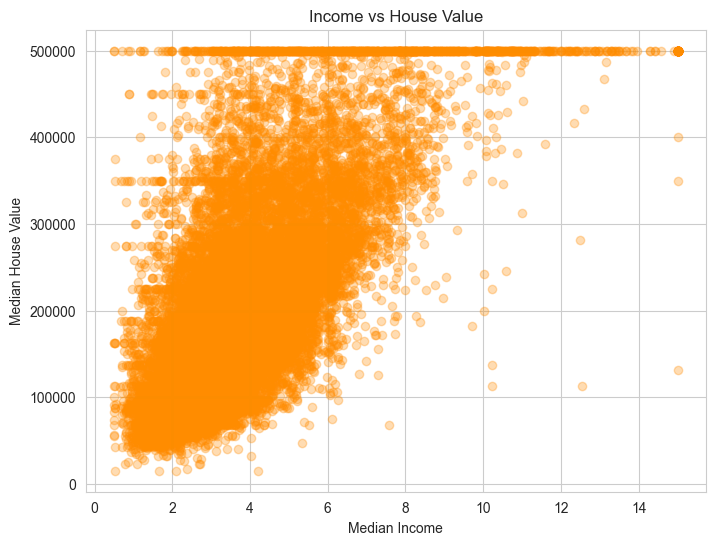

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3, color='darkorange')
plt.xlabel('Median Income'); plt.ylabel('Median House Value')
plt.title('Income vs House Value')
plt.savefig('viz_income_vs_value.png', dpi=100)
plt.show()

### House value by ocean proximity

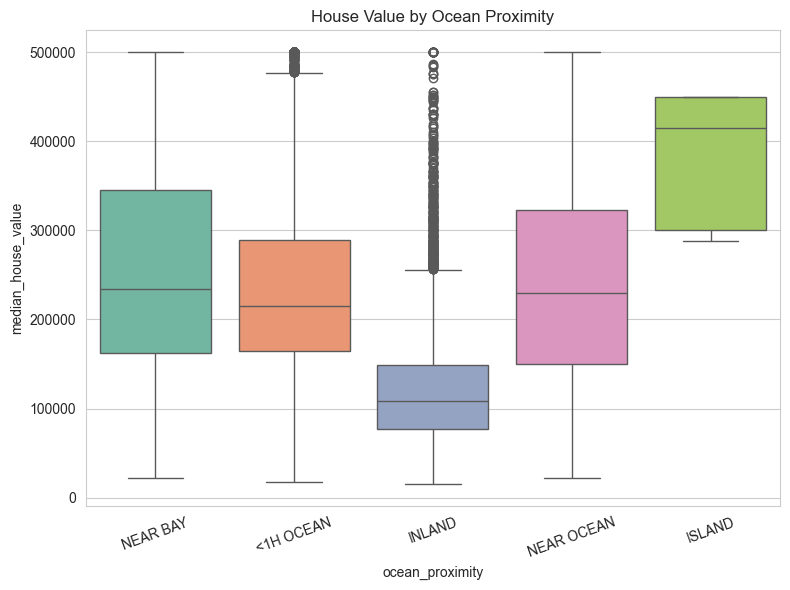

In [42]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', hue='ocean_proximity', palette='Set2', legend=False)
plt.xticks(rotation=20)
plt.title('House Value by Ocean Proximity')
plt.tight_layout()
plt.show()

## 4. Linear Regression — predicting `median_house_value`

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df_encoded.drop(columns=['median_house_value'])
y = df_encoded['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'RMSE: {rmse:,.2f}')
print(f'MAE:  {mae:,.2f}')
print(f'R2:   {r2:.4f}')

RMSE: 62,449.29
MAE:  44,994.12
R2:   0.5862


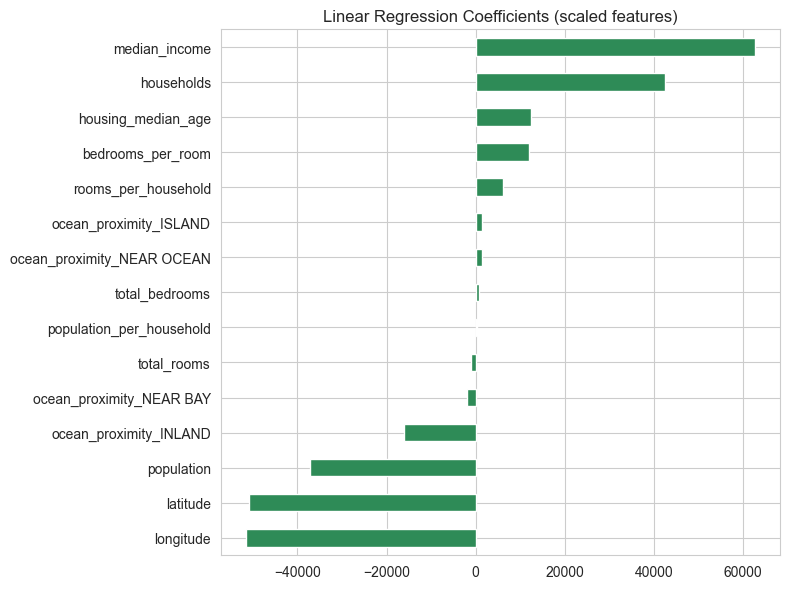

In [46]:
coef_df = pd.Series(lin_reg.coef_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
coef_df.plot(kind='barh', color='seagreen')
plt.title('Linear Regression Coefficients (scaled features)')
plt.tight_layout()

plt.show()

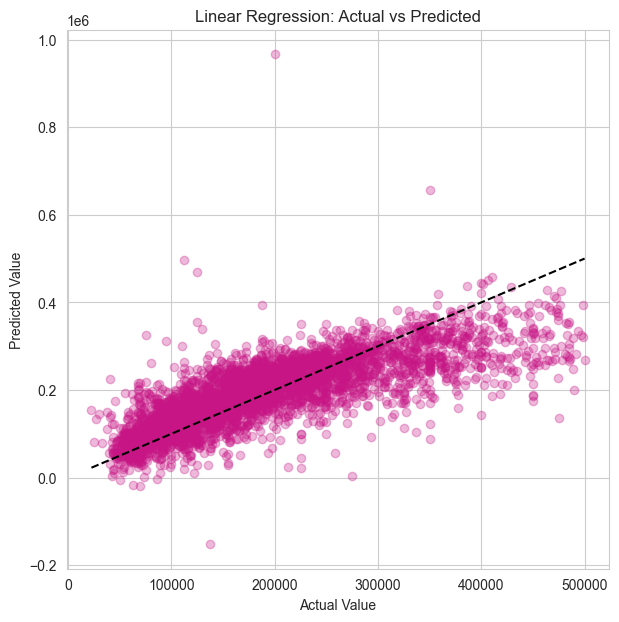

In [48]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color='mediumvioletred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel('Actual Value'); plt.ylabel('Predicted Value')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

## 5. Logistic Regression — classifying "expensive" vs "affordable" homes
Logistic regression needs a classification target, so we binarize `median_house_value` at its median.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

threshold = df_encoded['median_house_value'].median()
y_class = (df_encoded['median_house_value'] > threshold).astype(int)
print(f'Threshold: {threshold:,.0f}')
print(y_class.value_counts())

Threshold: 173,800
median_house_value
0    9841
1    9834
Name: count, dtype: int64


In [51]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train2_scaled, y_train2)
y_pred2 = log_reg.predict(X_test2_scaled)
y_proba2 = log_reg.predict_proba(X_test2_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test2, y_pred2):.4f}')
print()
print(classification_report(y_test2, y_pred2, target_names=['Affordable', 'Expensive']))

Accuracy: 0.8394

              precision    recall  f1-score   support

  Affordable       0.85      0.82      0.84      1968
   Expensive       0.83      0.85      0.84      1967

    accuracy                           0.84      3935
   macro avg       0.84      0.84      0.84      3935
weighted avg       0.84      0.84      0.84      3935



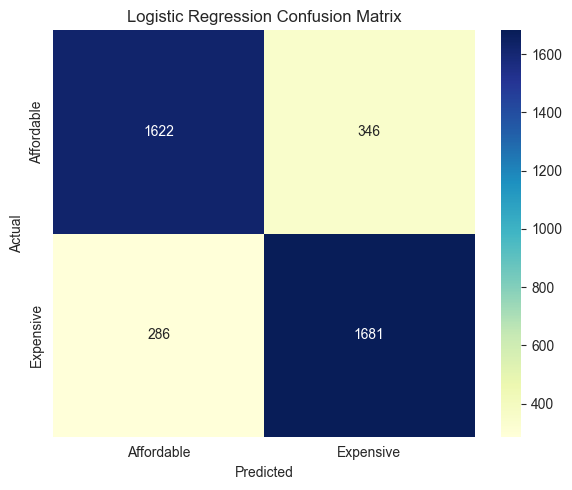

In [52]:
cm = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Affordable', 'Expensive'], yticklabels=['Affordable', 'Expensive'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.savefig('viz_confusion.png', dpi=100)
plt.show()

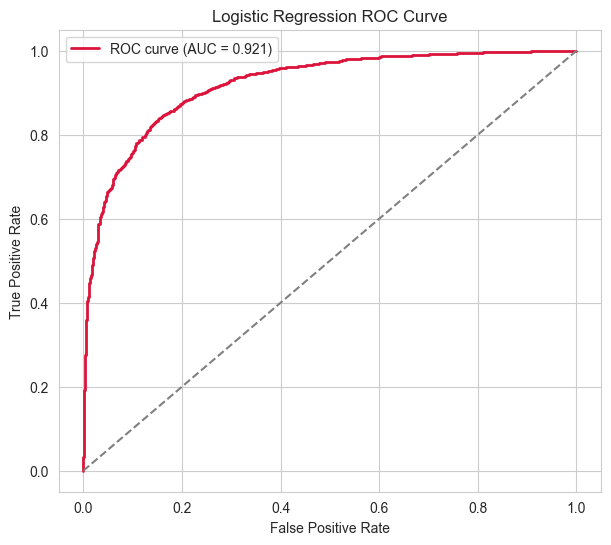

In [53]:
fpr, tpr, _ = roc_curve(y_test2, y_proba2)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='crimson', linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.savefig('viz_roc.png', dpi=100)
plt.show()